# DM Verification Jobs Runner

This notebook runs all DM verification jobs with progress tracking.

Features:

- Runs jobs sequentially with progress tracking
- Saves progress to resume if interrupted
- Shows detailed statistics and progress bars
- Handles errors gracefully


In [2]:
import os
import subprocess
import json
from pathlib import Path
from datetime import datetime
from tqdm import tqdm
import time
import sys

# Configuration
DEVICES = ['S']  # Device types to test
CHANNELS = ['dephasing']
AMPS = [1e-9]

# Alpha pattern configurations (matching generate_dm_verification_jobs.py)
#ALPHA_PATTERNS = {
#    'nq/4': [4,8],
#    'nq/2': [4,6,8,10],
#    '3/4nq': [4,8],
#    'nq': [4,6,8,10]
#}

ALPHA_PATTERNS = {
    'nq/4': [],
    'nq/2': [8,10],
    '3/4nq': [],
    'nq': [2,3,4,5,6,7,8,9,10]
}

# Script parameters
SCRIPT_PATH = "quantum_run_dm_verification.py"
NUM_F_STATES = 1000
SHOTS_PER_F = 1000
F_SEED = 1234

# Python interpreter to use (per user preference: Python 3.9.6 at /usr/bin/python3)
PYTHON_CMD = "/usr/bin/python3"

# Progress tracking file
PROGRESS_FILE = "dm_verification_progress.json"

print("✅ Imports loaded")

✅ Imports loaded


In [3]:
def generate_job_list():
    """Generate list of all jobs to run."""
    jobs = []
    job_id = 0
    
    for device in DEVICES:
        for channel in CHANNELS:
            for alpha_pattern, nq_values in ALPHA_PATTERNS.items():
                for nq in nq_values:
                    for amp in AMPS:
                        job_id += 1
                        job = {
                            'id': job_id,
                            'device': device,
                            'channel': channel,
                            'nq': nq,
                            'alpha_pattern': alpha_pattern,
                            'amp': amp,
                            'command': f"{PYTHON_CMD} {SCRIPT_PATH} --device {device} --channel {channel} --nq {nq} --alpha_pattern {alpha_pattern} --amp {amp} --nf {NUM_F_STATES} --shots {SHOTS_PER_F} --f_seed {F_SEED}",
                            'status': 'pending',  # pending, running, completed, failed
                            'start_time': None,
                            'end_time': None,
                            'error': None
                        }
                        jobs.append(job)
    
    return jobs

def load_progress():
    """Load progress from file if it exists."""
    if Path(PROGRESS_FILE).exists():
        with open(PROGRESS_FILE, 'r') as f:
            return json.load(f)
    return None

def save_progress(jobs, stats):
    """Save current progress to file."""
    progress = {
        'last_updated': datetime.now().isoformat(),
        'jobs': jobs,
        'stats': stats
    }
    with open(PROGRESS_FILE, 'w') as f:
        json.dump(progress, f, indent=2)

def get_job_key(job):
    """Get unique key for a job."""
    return f"{job['device']}_{job['channel']}_{job['nq']}_{job['alpha_pattern']}_{job['amp']}"

print("✅ Helper functions defined")

✅ Helper functions defined


In [4]:
# Generate or load job list
print("Loading or generating job list...")
progress_data = load_progress()

if progress_data:
    print(f"📂 Found existing progress file (last updated: {progress_data['last_updated']})")
    jobs = progress_data['jobs']
    print(f"   Resuming with {len(jobs)} jobs")
else:
    print("🆕 Generating new job list...")
    jobs = generate_job_list()
    print(f"   Generated {len(jobs)} jobs")

# Initialize statistics
stats = {
    'total': len(jobs),
    'completed': sum(1 for j in jobs if j['status'] == 'completed'),
    'failed': sum(1 for j in jobs if j['status'] == 'failed'),
    'pending': sum(1 for j in jobs if j['status'] == 'pending'),
    'running': sum(1 for j in jobs if j['status'] == 'running')
}

print(f"\n📊 Current Status:")
print(f"   Total jobs: {stats['total']}")
print(f"   ✅ Completed: {stats['completed']}")
print(f"   ❌ Failed: {stats['failed']}")
print(f"   ⏳ Pending: {stats['pending']}")
print(f"   🔄 Running: {stats['running']}")

Loading or generating job list...
🆕 Generating new job list...
   Generated 11 jobs

📊 Current Status:
   Total jobs: 11
   ✅ Completed: 0
   ❌ Failed: 0
   ⏳ Pending: 11
   🔄 Running: 0


In [5]:
def run_job(job, cwd=None):
    """Run a single job and return success status."""
    job['status'] = 'running'
    job['start_time'] = datetime.now().isoformat()
    
    try:
        # Split command properly - handle the Python path and script separately
        cmd_parts = job['command'].split()
        python_cmd = cmd_parts[0]
        script_args = cmd_parts[1:]
        
        # Create error log file name for this job
        # Replace "/" in alpha_pattern with "_" for filesystem compatibility
        alpha_safe = job['alpha_pattern'].replace('/', '_')
        job_key = f"{job['device']}_{job['channel']}_nq{job['nq']}_{alpha_safe}_amp{job['amp']}"
        log_dir = Path(cwd) / "dm_verification_logs"
        log_dir.mkdir(exist_ok=True)
        err_file = log_dir / f"{job_key}.err"
        out_file = log_dir / f"{job_key}.out"
        
        # Run job and write stderr to file, stdout to file
        with open(err_file, 'w') as f_err, open(out_file, 'w') as f_out:
            result = subprocess.run(
                [python_cmd] + script_args,
                cwd=cwd,
                stdout=f_out,  # Write stdout to file
                stderr=f_err,  # Write stderr directly to file (includes debug output)
                text=True,
                timeout=3600  # 1 hour timeout per job
            )
        
        # Print location of log files
        print(f"  📄 Logs saved to: {err_file.name} and {out_file.name}")
        
        if result.returncode == 0:
            job['status'] = 'completed'
            job['end_time'] = datetime.now().isoformat()
            return True
        else:
            job['status'] = 'failed'
            # Read error from file
            with open(err_file, 'r') as f:
                error_content = f.read()
                job['error'] = error_content[:500] if error_content else "Unknown error"
            job['end_time'] = datetime.now().isoformat()
            return False
            
    except subprocess.TimeoutExpired:
        job['status'] = 'failed'
        job['error'] = "Job timed out after 1 hour"
        job['end_time'] = datetime.now().isoformat()
        return False
    except Exception as e:
        job['status'] = 'failed'
        job['error'] = str(e)[:500]
        job['end_time'] = datetime.now().isoformat()
        return False

print("✅ Job execution function defined")

✅ Job execution function defined


In [6]:
# Main execution loop
# Set this to True to actually run jobs, False to just show what would run
RUN_JOBS = True

# Get the working directory - adjust this path if needed
WORK_DIR = Path.cwd()
# If we're not already in quantum_simulation, try to find it
if 'quantum_simulation' not in str(WORK_DIR):
    # Try relative path
    potential_path = WORK_DIR / 'code' / 'quantum_simulation'
    if potential_path.exists():
        WORK_DIR = potential_path
    else:
        # Try absolute path based on common structure
        potential_path = Path('/Users/krzywdaja/Documents/shadows/shadow-qml-cluster/code/quantum_simulation')
        if potential_path.exists():
            WORK_DIR = potential_path

print(f"📁 Working directory: {WORK_DIR}")
print(f"🐍 Python command: {PYTHON_CMD}")
print(f"🚀 Run jobs: {RUN_JOBS}")

if RUN_JOBS:
    print("\n" + "="*80)
    print("Starting job execution...")
    print("="*80)
    
    # Filter to only pending jobs
    pending_jobs = [j for j in jobs if j['status'] == 'pending']
    
    if not pending_jobs:
        print("✅ All jobs are already completed or failed!")
    else:
        print(f"📋 Running {len(pending_jobs)} pending jobs...\n")
        
        # Create progress bar
        pbar = tqdm(total=len(pending_jobs), desc="Jobs", unit="job")
        
        for i, job in enumerate(pending_jobs, 1):
            job_desc = f"{job['device']}-{job['channel']}-nq{job['nq']}-{job['alpha_pattern']}-amp{job['amp']}"
            pbar.set_description(f"Job {i}/{len(pending_jobs)}: {job_desc}")
            
            success = run_job(job, cwd=WORK_DIR)
            
            # Update statistics
            if success:
                stats['completed'] += 1
                stats['pending'] -= 1
            else:
                stats['failed'] += 1
                stats['pending'] -= 1
            
            # Save progress after each job
            save_progress(jobs, stats)
            
            pbar.update(1)
            
            # Print job result
            if success:
                print(f"  ✅ Job {i} completed: {job_desc}")
            else:
                print(f"  ❌ Job {i} failed: {job_desc}")
                if job.get('error'):
                    print(f"     Error: {job['error'][:200]}")
        
        pbar.close()
        
        print("\n" + "="*80)
        print("Job execution complete!")
        print("="*80)
else:
    print("\n⚠️  RUN_JOBS is False - jobs will not be executed")
    print("   Set RUN_JOBS = True to actually run the jobs")

📁 Working directory: /Users/krzywdaja/Documents/shadows/shadow-qml-cluster/code/quantum_simulation
🐍 Python command: /usr/bin/python3
🚀 Run jobs: True

Starting job execution...
📋 Running 11 pending jobs...



Job 1/11: S-dephasing-nq8-nq/2-amp1e-09:   0%|          | 0/11 [00:00<?, ?job/s]

Job 2/11: S-dephasing-nq10-nq/2-amp1e-09:   9%|▉         | 1/11 [01:40<16:49, 100.95s/job]

  📄 Logs saved to: S_dephasing_nq8_nq_2_amp1e-09.err and S_dephasing_nq8_nq_2_amp1e-09.out
  ✅ Job 1 completed: S-dephasing-nq8-nq/2-amp1e-09


Job 3/11: S-dephasing-nq2-nq-amp1e-09:  18%|█▊        | 2/11 [06:05<29:34, 197.16s/job]   

...

  📄 Logs saved to: S_dephasing_nq8_nq_amp1e-09.err and S_dephasing_nq8_nq_amp1e-09.out
  ✅ Job 9 completed: S-dephasing-nq8-nq-amp1e-09


Job 11/11: S-dephasing-nq10-nq-amp1e-09:  91%|█████████ | 10/11 [16:47<01:54, 114.42s/job]

  📄 Logs saved to: S_dephasing_nq9_nq_amp1e-09.err and S_dephasing_nq9_nq_amp1e-09.out
  ✅ Job 10 completed: S-dephasing-nq9-nq-amp1e-09


Job 11/11: S-dephasing-nq10-nq-amp1e-09: 100%|██████████| 11/11 [22:22<00:00, 122.01s/job]

  📄 Logs saved to: S_dephasing_nq10_nq_amp1e-09.err and S_dephasing_nq10_nq_amp1e-09.out
  ✅ Job 11 completed: S-dephasing-nq10-nq-amp1e-09

Job execution complete!


In [6]:
# Control Plot: Accuracy vs Device and Amplitude (for fixed nq)
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

# Configuration - set the nq you want to plot
PLOT_NQ = 8  # Change this to the nq you want to plot
OUTPUT_BASE_DIR = Path("dm_verification_results")

def load_dm_results(device, channel, nq, amp, alpha_pattern):
    """Load DM verification results for a specific configuration."""
    alpha_safe = alpha_pattern.replace('/', '_')
    result_dir = OUTPUT_BASE_DIR / f"nq{nq}_amp{amp}_{device}_{channel}_{alpha_safe}"
    acc_file = result_dir / f"acc_dm_nq{nq}.npy"
    
    if not acc_file.exists():
        return None
    
    # Load accuracy results
    # Shape: (1, 1, nq_index, channel_index, num_f_states)
    acc_data = np.load(acc_file)
    
    # Extract the accuracy values (flatten the first dimensions)
    # acc_data shape is (1, 1, 1, 1, num_f_states) for a single nq/channel
    accuracies = acc_data.flatten()
    
    return accuracies

def create_control_plot(nq, channel='dephasing', alpha_pattern='nq/4'):
    """Create control plot showing accuracy with error bars for each device and amplitude."""
    
    # Collect data
    data = {}
    
    for device in DEVICES:
        for amp in AMPS:
            key = (device, amp)
            accuracies = load_dm_results(device, channel, nq, amp, alpha_pattern)
            if accuracies is not None:
                data[key] = accuracies
            else:
                print(f"⚠️  Missing data for device={device}, amp={amp}, nq={nq}, channel={channel}, alpha={alpha_pattern}")
    
    if not data:
        print(f"❌ No data found for nq={nq}, channel={channel}, alpha_pattern={alpha_pattern}")
        return
    
    # Prepare data for plotting
    devices_plot = []
    amps_plot = []
    means = []
    stds = []
    std_errors = []
    
    for device in DEVICES:
        for amp in AMPS:
            key = (device, amp)
            if key in data:
                acc = data[key]
                devices_plot.append(device)
                amps_plot.append(amp)
                means.append(np.mean(acc))
                stds.append(np.std(acc))
                std_errors.append(np.std(acc) / np.sqrt(len(acc)))  # Standard error of the mean
    
    # Create figure with subplots for each amplitude
    fig, axes = plt.subplots(1, len(AMPS), figsize=(6*len(AMPS), 6), sharey=True)
    if len(AMPS) == 1:
        axes = [axes]
    
    for amp_idx, amp in enumerate(AMPS):
        ax = axes[amp_idx]
        
        # Filter data for this amplitude
        amp_means = []
        amp_errors = []
        amp_devices = []
        
        for device in DEVICES:
            key = (device, amp)
            if key in data:
                idx = list(zip(devices_plot, amps_plot)).index((device, amp))
                amp_means.append(means[idx])
                amp_errors.append(std_errors[idx])  # Use standard error for error bars
                amp_devices.append(device)
        
        if amp_means:
            x_pos = np.arange(len(amp_devices))
            bars = ax.bar(x_pos, amp_means, yerr=amp_errors, capsize=5, 
                         alpha=0.7, edgecolor='black', linewidth=1.5)
            
            # Color bars by device
            colors = {'I': '#1f77b4', 'R': '#ff7f0e', 'T': '#2ca02c', 'S': '#d62728'}
            for i, device in enumerate(amp_devices):
                bars[i].set_color(colors.get(device, 'gray'))
            
            ax.set_xlabel('Device', fontsize=12, fontweight='bold')
            ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
            ax.set_title(f'Amplitude = {amp}\nnq={nq}, channel={channel}, α={alpha_pattern}', 
                        fontsize=13, fontweight='bold')
            ax.set_xticks(x_pos)
            ax.set_xticklabels(amp_devices, fontsize=11)
            ax.grid(True, alpha=0.3, axis='y')
            ax.set_ylim([0, 1.1])
            
            # Add value labels on bars
            for i, (mean, error) in enumerate(zip(amp_means, amp_errors)):
                ax.text(i, mean + error + 0.02, f'{mean:.4f}\n±{error:.4f}', 
                       ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(f'dm_control_plot_nq{nq}_{channel}_{alpha_pattern.replace("/", "_")}.png', 
                dpi=150, bbox_inches='tight')
    print(f"✅ Plot saved: dm_control_plot_nq{nq}_{channel}_{alpha_pattern.replace('/', '_')}.png")
    plt.show()
    
    # Print summary statistics
    print(f"\n📊 Summary Statistics for nq={nq}, channel={channel}, alpha_pattern={alpha_pattern}:")
    print("="*80)
    for device in DEVICES:
        print(f"\nDevice {device}:")
        for amp in AMPS:
            key = (device, amp)
            if key in data:
                acc = data[key]
                mean = np.mean(acc)
                std = np.std(acc)
                std_err = std / np.sqrt(len(acc))
                print(f"  Amplitude {amp}: {mean:.6f} ± {std_err:.6f} (std: {std:.6f}, N={len(acc)})")

# Create plot for the configured nq
print(f"Creating control plot for nq={PLOT_NQ}...")
for channel in CHANNELS:
    for alpha_pattern in ALPHA_PATTERNS.keys():
        if PLOT_NQ in ALPHA_PATTERNS[alpha_pattern]:
            print(f"\n{'='*80}")
            print(f"Plotting: nq={PLOT_NQ}, channel={channel}, alpha_pattern={alpha_pattern}")
            print(f"{'='*80}")
            create_control_plot(PLOT_NQ, channel=channel, alpha_pattern=alpha_pattern)


Creating control plot for nq=8...


Loading results from: dm_verification_results/nq3_amp1e-09_S2_dephasing_nq
Loading results from: dm_verification_results/nq4_amp1e-09_S2_dephasing_nq
Loading results from: dm_verification_results/nq5_amp1e-09_S2_dephasing_nq
Loading results from: dm_verification_results/nq6_amp1e-09_S2_dephasing_nq
Loading results from: dm_verification_results/nq7_amp1e-09_S2_dephasing_nq
Loading results from: dm_verification_results/nq8_amp1e-09_S2_dephasing_nq
Loading results from: dm_verification_results/nq9_amp1e-09_S2_dephasing_nq
Loading results from: dm_verification_results/nq10_amp1e-09_S2_dephasing_nq
✅ Plot saved: accuracy_vs_nq_dephasing_nq.png


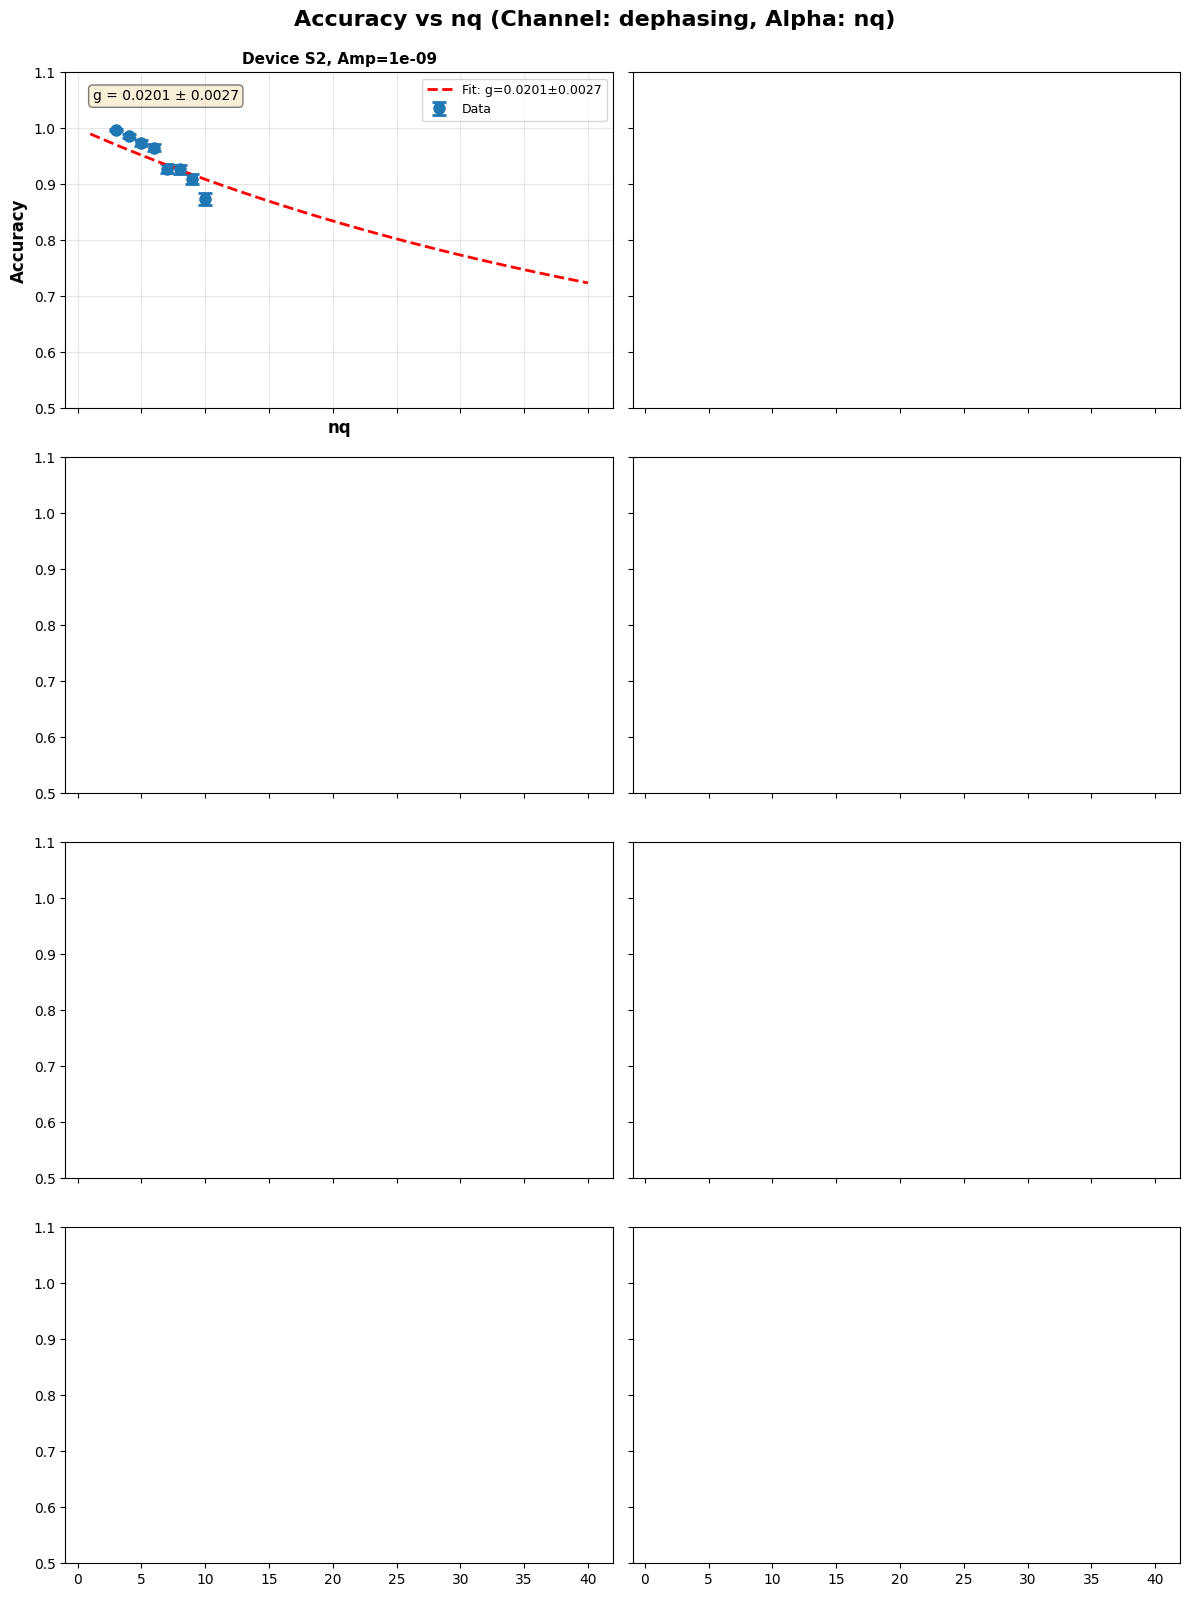


📊 Fit Parameter Summary (g values):

Device S2:
  Amp 1e-09: g = 0.020070 ± 0.002726


In [8]:
# Plot accuracy as a function of nq with exponential fit
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit

# Configuration
OUTPUT_BASE_DIR = Path("dm_verification_results")
CHANNEL = 'dephasing'  # or 'relaxation'
ALPHA_PATTERN = 'nq'
NQ_VALUES = [3,4,5,6,7,8,9, 10]
AMPS = [1e-9]
DEVICES = ['S2']

def load_dm_results(device, channel, nq, amp, alpha_pattern):
    """Load DM verification results for a specific configuration."""
    alpha_safe = alpha_pattern.replace('/', '_')
    result_dir = OUTPUT_BASE_DIR / f"nq{nq}_amp{amp}_{device}_{channel}_{alpha_safe}"
    print(f"Loading results from: {result_dir}")
    acc_file = result_dir / f"acc_dm_nq{nq}.npy"
    
    if not acc_file.exists():
        return None
    
    # Load accuracy results
    # Shape: (1, 1, 1, num_f_states)
    acc_data = np.load(acc_file)
    
    # Extract the accuracy values (flatten to get all f states)
    accuracies = acc_data.flatten()
    
    return accuracies

def exp_fit_func(nq, g):
    """Exponential decay function: 1/2 + 1/2*exp(-g*nq)"""
    return 0.5 + 0.5 * np.exp(-g * nq)

# Collect data for all configurations
data_dict = {}
for device in DEVICES:
    for amp in AMPS:
        key = (device, amp)
        data_dict[key] = {'nq': [], 'mean': [], 'std': []}
        
        for nq in NQ_VALUES:
            accuracies = load_dm_results(device, CHANNEL, nq, amp, ALPHA_PATTERN)
            if accuracies is not None:
                data_dict[key]['nq'].append(nq)
                data_dict[key]['mean'].append(np.mean(accuracies))
                data_dict[key]['std'].append(np.std(accuracies))
            else:
                print(f"⚠️  Missing data for device={device}, amp={amp}, nq={nq}")

# Create figure with grid: 4 rows (devices) x 2 columns (amplitudes)
fig, axes = plt.subplots(4, 2, figsize=(12, 16), sharex=True, sharey=True)
fig.suptitle(f'Accuracy vs nq (Channel: {CHANNEL}, Alpha: {ALPHA_PATTERN})', 
             fontsize=16, fontweight='bold', y=0.995)

# Plot each device and amplitude combination
for device_idx, device in enumerate(DEVICES):
    for amp_idx, amp in enumerate(AMPS):
        ax = axes[device_idx, amp_idx]
        key = (device, amp)
        
        if len(data_dict[key]['nq']) > 0:
            nq_array = np.array(data_dict[key]['nq'])
            mean_array = np.array(data_dict[key]['mean'])
            std_array = np.array(data_dict[key]['std'])
            
            # Plot data points with error bars
            ax.errorbar(nq_array, mean_array, yerr=std_array, 
                       fmt='o', capsize=5, capthick=2, markersize=8,
                       label='Data', color='#1f77b4', linewidth=2)
            
            # Fit exponential function
            try:
                # Initial guess for g (decay parameter)
                # We'll use a reasonable starting value
                popt, pcov = curve_fit(exp_fit_func, nq_array, mean_array, 
                                     p0=[0.1], maxfev=5000)
                g_fit = popt[0]
                g_err = np.sqrt(pcov[0, 0])
                

                # Generate smooth curve for plotting
                nq_fit = np.linspace(1, 40, 100)
                y_fit = exp_fit_func(nq_fit, g_fit)
                
                # Plot fitted curve
                ax.plot(nq_fit, y_fit, 'r--', linewidth=2, 
                       label=f'Fit: g={g_fit:.4f}±{g_err:.4f}')
                
                # Add fit info to plot
                ax.text(0.05, 0.95, f'g = {g_fit:.4f} ± {g_err:.4f}', 
                       transform=ax.transAxes, fontsize=10,
                       verticalalignment='top', bbox=dict(boxstyle='round', 
                       facecolor='wheat', alpha=0.5))
            except Exception as e:
                print(f"⚠️  Fit failed for device={device}, amp={amp}: {e}")
            
            # Set labels and title
            if device_idx == len(DEVICES) - 1:
                ax.set_xlabel('nq', fontsize=12, fontweight='bold')
            if amp_idx == 0:
                ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
            
            ax.set_title(f'Device {device}, Amp={amp}', fontsize=11, fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.set_ylim([0.5, 1.1])
            ax.legend(loc='best', fontsize=9)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', 
                   transform=ax.transAxes, fontsize=12)
            ax.set_title(f'Device {device}, Amp={amp}', fontsize=11, fontweight='bold')
            ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'accuracy_vs_nq_{CHANNEL}_{ALPHA_PATTERN.replace("/", "_")}.png', 
            dpi=150, bbox_inches='tight')
print(f"✅ Plot saved: accuracy_vs_nq_{CHANNEL}_{ALPHA_PATTERN.replace('/', '_')}.png")
plt.show()

# Print summary of fit parameters
print(f"\n📊 Fit Parameter Summary (g values):")
print("="*80)
for device in DEVICES:
    print(f"\nDevice {device}:")
    for amp in AMPS:
        key = (device, amp)
        if len(data_dict[key]['nq']) > 0:
            try:
                nq_array = np.array(data_dict[key]['nq'])
                mean_array = np.array(data_dict[key]['mean'])
                popt, pcov = curve_fit(exp_fit_func, nq_array, mean_array, 
                                     p0=[0.1], maxfev=5000)
                g_fit = popt[0]
                g_err = np.sqrt(pcov[0, 0])
                print(f"  Amp {amp}: g = {g_fit:.6f} ± {g_err:.6f}")
            except:
                print(f"  Amp {amp}: Fit failed")


In [ ]:
# Final statistics
print("\n" + "="*80)
print("📊 FINAL STATISTICS")
print("="*80)

# Reload to get latest stats
progress_data = load_progress()
if progress_data:
    stats = progress_data['stats']
    jobs = progress_data['jobs']

print(f"\nTotal jobs: {stats['total']}")
print(f"✅ Completed: {stats['completed']} ({100*stats['completed']/stats['total']:.1f}%)")
print(f"❌ Failed: {stats['failed']} ({100*stats['failed']/stats['total']:.1f}%)")
print(f"⏳ Pending: {stats['pending']} ({100*stats['pending']/stats['total']:.1f}%)")

# Breakdown by device
print("\n📈 Breakdown by Device:")
for device in DEVICES:
    device_jobs = [j for j in jobs if j['device'] == device]
    completed = sum(1 for j in device_jobs if j['status'] == 'completed')
    failed = sum(1 for j in device_jobs if j['status'] == 'failed')
    print(f"  {device}: {completed}/{len(device_jobs)} completed, {failed} failed")

# Breakdown by channel
print("\n📈 Breakdown by Channel:")
for channel in CHANNELS:
    channel_jobs = [j for j in jobs if j['channel'] == channel]
    completed = sum(1 for j in channel_jobs if j['status'] == 'completed')
    failed = sum(1 for j in channel_jobs if j['status'] == 'failed')
    print(f"  {channel}: {completed}/{len(channel_jobs)} completed, {failed} failed")

# Show failed jobs if any
failed_jobs = [j for j in jobs if j['status'] == 'failed']
if failed_jobs:
    print(f"\n❌ Failed Jobs ({len(failed_jobs)}):")
    for job in failed_jobs[:10]:  # Show first 10
        job_desc = f"{job['device']}-{job['channel']}-nq{job['nq']}-{job['alpha_pattern']}-amp{job['amp']}"
        print(f"  - {job_desc}")
        if job.get('error'):
            print(f"    Error: {job['error'][:100]}")
    if len(failed_jobs) > 10:
        print(f"  ... and {len(failed_jobs) - 10} more")

print(f"\n💾 Progress saved to: {PROGRESS_FILE}")

In [ ]:
# Optional: Reset progress (uncomment to start fresh)
# WARNING: This will delete all progress tracking!
# RESET_PROGRESS = False

# if RESET_PROGRESS:
#     if Path(PROGRESS_FILE).exists():
#         Path(PROGRESS_FILE).unlink()
#         print("🗑️  Progress file deleted. Run the cells above to start fresh.")
#     else:
#         print("ℹ️  No progress file to delete.")